In [4]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "test_001_nvda").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# Keep the strategy gate local to the notebook so analysis uses the exact same
# signal definition as model generation.
def add_gate_signals(df):
    df = df.copy()
    df["buy_signal"] = (
        (df["macd_line"] > df["macd_signal"])
        & (df["macd_line"].shift(1) <= df["macd_signal"].shift(1))
        & (df["rsi"] > 50)
    )
    df["sell_signal"] = (
        (df["macd_line"] < df["macd_signal"])
        & (df["macd_line"].shift(1) >= df["macd_signal"].shift(1))
        & (df["rsi"] < 50)
    )
    return df

STRATEGY_DIR = repo_root / "backtesting" / "test_001_nvda"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

result, result_path = common.load_latest_backtest(STRATEGY_DIR)
state = result.get("state", {})
print(f"Run:     {result_path.parent.name}")
print(f"Status:  {state.get('Status')}")
print(f"Orders:  {state.get('OrderCount', 0)}")

Run:     2026-03-24_01-49-07
Status:  Completed
Orders:  0


In [5]:
# Rebuild the indicator frame over the exact backtest window so the dashboard can
# overlay the same buy/sell gates used during training.
algo_cfg = result.get("algorithmConfiguration", {})
period_start = algo_cfg.get("startDate", config.get("backtest_start", ""))[:10]
period_end = algo_cfg.get("endDate", config.get("backtest_end", ""))[:10]

df = common.fetch_ohlcv(
    config["stock_symbol"],
    start=period_start,
    end=period_end,
    provider=config["data_src"],
)
df = common.add_indicators(df).pipe(add_gate_signals).dropna()

print(f"Price data:  {df.index[0]} -> {df.index[-1]}  ({len(df)} bars)")
print(f"Buy signals: {df['buy_signal'].sum()}")
print(f"Sell signals: {df['sell_signal'].sum()}")

Price data:  2022-01-31 00:00:00 -> 2022-12-30 00:00:00  (232 bars)
Buy signals: 4
Sell signals: 7


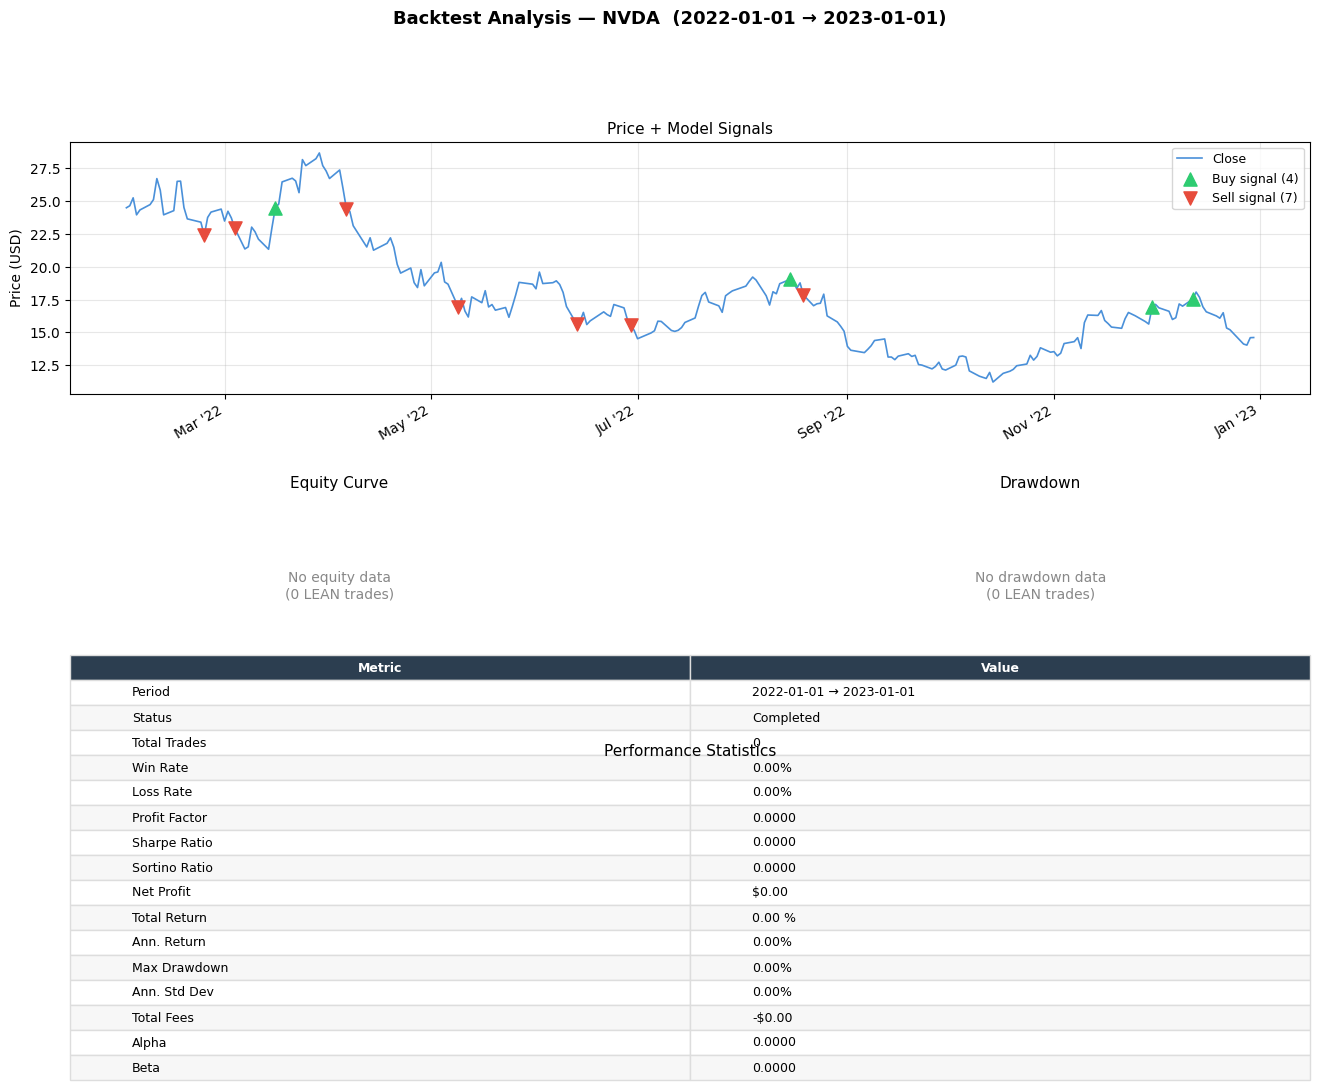

In [6]:
fig = common.backtest_dashboard(
    price_df=df,
    result=result,
    symbol=config["stock_symbol"],
    initial_cash=config.get("initial_cash", 100_000),
)
fig.savefig(STRATEGY_DIR / "backtests" / result_path.parent.name / "dashboard.png",
            dpi=150, bbox_inches="tight")